## To Do

1. **Research GMM criteria** — add to Overleaf LaTeX file -DONE, just need to add to LaTeX file
2. **Cut original FITS file** and cluster with **WADERS**  
3. **Cut calibrated FITS file** and cluster with **GMM**  
4. **Generate comparison plots:**
   - a. Energy vs. STD of cluster (for each)
   - b. Energy vs. Size of cluster (for each)
   - c. Energy spectrum of clusters
5. **Comparison and analysis**


In [2]:
import pysimdamicm
import pysimdamicm.scripts
print("pysimdamicm:", pysimdamicm.__file__)
print("scripts:", pysimdamicm.scripts.__file__)

pysimdamicm: None
scripts: None


## Imports

In [3]:
import pysimdamicm

import ROOT

import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib
import matplotlib.pyplot as plt

In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.measure import label, regionprops

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [5]:
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.default"] = "regular"

### Helpers

Thresholding options

In [6]:
# helper to make threshold cut to image to remove noise
def apply_percentile_threshold(cal_img, percentile=95, fill_value=np.nan):
    """
    Apply a global percentile cut on the RAW calibrated image (E in e-).
    Pixels <= threshold are set to `fill_value` (np.nan by default).

    Returns:
      masked_img : 2D array with only >thr pixels kept
      thr        : numeric threshold used
      keep       : boolean mask (True for kept pixels)
    """
    thr = np.percentile(cal_img, percentile)  # compute on RAW E
    keep = cal_img > thr                      # strict '>' to drop exactly bottom p%
    masked_img = np.where(keep, cal_img, fill_value)
    return masked_img, thr, keep

In [7]:
def apply_energy_threshold(cal_img, thr_keV, fill_value=np.nan):
    """
    Apply a fixed energy threshold to a CCD image calibrated in keV.
    Pixels with energy <= thr_keV are masked out.

    Parameters
    ----------
    cal_img : 2D array (in keV)
        Calibrated CCD image.
    thr_keV : float
        Threshold in keV. Pixels <= thr_keV are suppressed.
    fill_value : number, optional
        Replacement value for masked-out pixels (default: NaN).

    Returns
    -------
    masked_img : 2D array
        Image keeping only pixels above threshold.
    thr_keV : float
        Echo of threshold used.
    keep : 2D boolean array
        True where pixel > thr_keV.
    """
    keep = cal_img > thr_keV
    masked_img = np.where(keep, cal_img, fill_value)
    return masked_img, thr_keV, keep

Make samples logged or not logged in E

In [8]:
# log scale data, may not be necessary but I think I used it for the original so will do it again
def make_samples_logE(masked_img):
    """
    Build N x 3 samples from a thresholded CCD image (in keV).
    Uses log(E) as the third feature.
    Assumes masked_img has NaNs or zeros removed already via thresholding.
    
    Returns:
      X_raw : (N,3) with columns [y, x, log(E)]
      idx_yx: (N,2) integer pixel coords [y, x]
    """
    valid = np.isfinite(masked_img) & (masked_img > 0)
    ys, xs = np.nonzero(valid)
    E = masked_img[ys, xs].astype(np.float64)

    # Use pure natural log
    logE = np.log(E)

    X_raw = np.column_stack([ys, xs, logE])
    idx_yx = np.column_stack([ys, xs])
    return X_raw, idx_yx

In [9]:
def make_samples(masked_img):
    """
    Build N x 3 samples from a thresholded CCD image (in keV).
    Uses raw E (no log) as the third feature.

    Returns:
      X_raw : (N,3) with columns [y, x, E]
      idx_yx: (N,2) integer pixel coords [y, x]
    """
    valid = np.isfinite(masked_img) & (masked_img > 0)
    ys, xs = np.nonzero(valid)
    E = masked_img[ys, xs].astype(np.float64)

    X_raw = np.column_stack([ys, xs, E])
    idx_yx = np.column_stack([ys, xs])
    return X_raw, idx_yx

Fit GMM

In [10]:
REG_COVAR = 1e-6
RANDOM_STATE = 209

def _unscale_covariances(gmm, scaler):
    """
    Map covariances from standardized space back to original feature space.
    Handles only covariance_type='full' (what you're using).
    """
    if gmm.covariance_type != "full":
        raise ValueError("This helper currently assumes covariance_type='full'.")

    D = np.diag(scaler.scale_)
    covs_std = gmm.covariances_                 # shape: (K, d, d)
    covs_raw = np.empty_like(covs_std)
    for k in range(covs_std.shape[0]):
        covs_raw[k] = D @ covs_std[k] @ D       # Σ_raw = D Σ_std D
    return covs_raw

def fit_gmms_over_K(X_raw, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE):
    """
    Standardize features, fit a full-covariance GMM for each K.
    Returns: list of dicts with model, labels, BIC, AIC, scaler, and
             means/covariances mapped back to ORIGINAL units.
    """
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_raw)

    results = []
    for K in K_RANGE:
        gmm = GaussianMixture(
            n_components=K,
            covariance_type="full",
            reg_covar=reg_covar,
            random_state=random_state
        )
        gmm.fit(X_std)

        # Predict labels in standardized space, but keep for reference
        labels = gmm.predict(X_std)

        # --- NEW: parameters in original (unscaled) space ---
        means_raw = scaler.inverse_transform(gmm.means_)       # shape: (K, d)
        covs_raw  = _unscale_covariances(gmm, scaler)          # shape: (K, d, d)

        bic = gmm.bic(X_std)
        aic = gmm.aic(X_std)
        results.append({
            "K": K,
            "model": gmm,
            "labels": labels,         # labels on the standardized X
            "bic": bic,
            "aic": aic,
            "scaler": scaler,
            "means_raw": means_raw,   # <-- in original units
            "covs_raw": covs_raw      # <-- in original units
        })

    results.sort(key=lambda r: r["bic"])
    return results

Plotting options

In [11]:
from matplotlib.colors import ListedColormap

def plot_fullframe_clusters(idx_yx, labels, frame_size=(320, 640), title=None):
    H, W = frame_size
    y = idx_yx[:, 0]
    x = idx_yx[:, 1]

    # ---- Build image storing cluster labels ----
    img = np.full((H, W), -1, dtype=int)
    img[y, x] = labels

    # ---- Define colors ----
    light_blue = [0.45, 0.75, 0.95, 1.0]   # clear light blue
    dark_pink  = [0.80, 0.10, 0.45, 1.0]   # strong pink/magenta

    colors = np.vstack([
        [1, 1, 1, 1],     # background = white
        light_blue,       # cluster 0
        dark_pink         # cluster 1
    ])

    cmap = ListedColormap(colors)

    img_plot = img + 1  # shift background (-1) → 0

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img_plot, origin='lower', cmap=cmap, interpolation='none')

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel("Column index (x)")
    ax.set_ylabel("Row index (y)")
    ax.set_title(title if title else "GMM clusters (full frame)")

    plt.tight_layout()
    plt.show()


In [12]:
def plot_cluster_gallery(idx_yx, result, max_points_per_cluster=None):
    """
    Plot the cluster gallery for a single (best) result.
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]

    K = result["K"]
    labels = result["labels"]

    ncols = int(np.ceil(np.sqrt(K)))
    nrows = int(np.ceil(K / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.2 * ncols, 3.2 * nrows),
        squeeze=False
    )
    fig.suptitle(f"GMM clusters (K={K}) — no overlay", y=0.98)

    rng = np.random.default_rng(209)

    for k in range(K):
        ax = axes[k // ncols][k % ncols]
        sel = (labels == k)

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        ax.scatter(x_all[sel], y_all[sel], s=2)
        ax.set_aspect("equal", "box")
        ax.set_title(f"Cluster {k}")
        ax.set_xlabel("x (col)")
        ax.set_ylabel("y (row)")

    for kk in range(K, nrows * ncols):
        axes[kk // ncols][kk % ncols].axis("off")

    plt.tight_layout()
    plt.show()


In [13]:
def plot_cluster_gallery_on_frame(idx_yx, result, ccd_shape, max_points_per_cluster=None):
    """
    Plot the cluster gallery for a single (best) result.
    Each panel shows the FULL CCD frame, with only that cluster overplotted.
    
    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    max_points_per_cluster : optional cap on points per cluster
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    ncols = int(np.ceil(np.sqrt(K)))
    nrows = int(np.ceil(K / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.6 * ncols, 3.6 * nrows),
        squeeze=False
    )
    fig.suptitle(f"GMM clusters (K={K}) — full-frame view", y=0.98)

    rng = np.random.default_rng(209)

    for k in range(K):
        ax = axes[k // ncols][k % ncols]
        sel = (labels == k)

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        # plot cluster points on full CCD frame
        ax.scatter(x_all[sel], y_all[sel], s=2)

        ax.set_xlim(0, W)
        ax.set_ylim(0, H)
        ax.set_aspect("equal", "box")

        ax.set_title(f"Cluster {k}")
        ax.set_xlabel("x (col)")
        ax.set_ylabel("y (row)")

    for kk in range(K, nrows * ncols):
        axes[kk // ncols][kk % ncols].axis("off")

    plt.tight_layout()
    plt.show()


In [14]:
from matplotlib.colors import ListedColormap

def plot_one_cluster(idx_yx, result, ccd_shape, cluster_id, origin="lower"):
    """
    imshow-style plot (like your example) but only for a single cluster_id.
    """
    H, W = ccd_shape
    labels = np.asarray(result["labels"])

    # pick points for this cluster
    sel = (labels == cluster_id)
    ys = np.asarray(idx_yx[:, 0], dtype=int)[sel]
    xs = np.asarray(idx_yx[:, 1], dtype=int)[sel]

    # make a 0/1 image for this cluster only
    img = np.zeros((H, W), dtype=np.uint8)
    img[ys, xs] = 1

    # colormap: background white, cluster blue (change if you want)
    cmap = ListedColormap(["white", "#1f77b4"])

    plt.figure(figsize=(6, 4))
    plt.imshow(img, origin=origin, cmap=cmap, interpolation="nearest", vmin=0, vmax=1)
    plt.title(f"GMM Cluster {cluster_id}")
    plt.xlabel("Column index (x)")
    plt.ylabel("Row index (y)")
    plt.tight_layout()
    plt.show()


### Calibrate cut image for GMM

In [15]:
# # Start with 1 raw image CCD (just took the first image 5)
# path = "raw_img_data/cutout_img_8.fz"
# json_file = "json/cut_img_8.json"

In [16]:
# from pysimdamicm.scripts.calibrate import calibrate

In [17]:
# calibrated_img = calibrate(path, json_file, save=False, return_array=True)

In [18]:
# ccds = np.vsplit(calibrated_img, 4)
# ccd1, ccd2, ccd3, ccd4 = ccds

In [19]:
# ccd1 = (ccd1 * 3.74)/1000

In [20]:
# ccd1.shape

In [21]:
# 80*120

In [22]:
# num_negatives = np.sum(ccd1 < 0)
# print(num_negatives)

In [23]:
# neg_mask = ccd1 < 0

# plt.figure(figsize=(16, 8))
# plt.imshow(
#     neg_mask,
#     origin="lower",
#     cmap="gray",
#     interpolation="none"
# )
# plt.colorbar(label="Negative pixel (True/False)")
# plt.title("Locations of Negative Pixels in CCD")
# plt.xlabel("Column index")
# plt.ylabel("Row index")
# plt.tight_layout()
# plt.show()


### Pull waders calibrated image

In [24]:
fits_path = "/home/dsalma/damicm-ml/cut_images/cut_images/cutout_img_8_EXT1_waders.fits"

with fits.open(fits_path) as hdul:
    hdul.info()

Filename: /home/dsalma/damicm-ml/cut_images/cut_images/cutout_img_8_EXT1_waders.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  CALIBRATED    1 PrimaryHDU     158   (120, 80)   float64   
  1  FULLMASK      1 ImageHDU         8   (120, 80)   float64   
  2  CLSMASK       1 ImageHDU         8   (120, 80)   float64   


In [25]:
with fits.open(fits_path) as hdul:
    cal_img = hdul[0].data

In [26]:
print("shape:", cal_img.shape)
print("type:", type(cal_img))
print("dtype:", cal_img.dtype)

shape: (80, 120)
type: <class 'numpy.ndarray'>
dtype: >f8


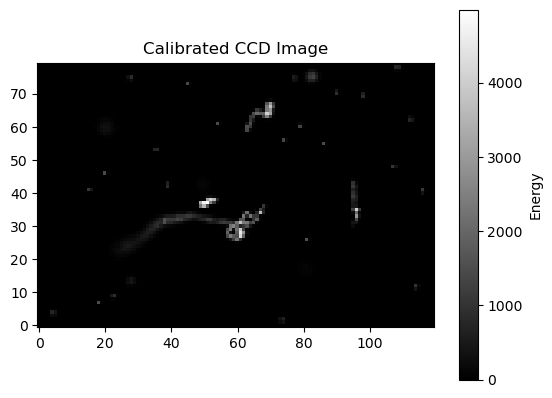

In [27]:
plt.imshow(cal_img, origin="lower", cmap="gray")
plt.colorbar(label="Energy")
plt.title("Calibrated CCD Image")
plt.show()

In [28]:
# convert image from calibration into electron into keV
cal_img = (cal_img * 3.74)/1000  # e- to keV

### GMM no background removal

In [29]:
# masked_img, thr, keep = apply_percentile_threshold(ccd1, percentile=99, fill_value=np.nan)

In [30]:
# plt.figure(figsize=(16, 8))
# cmap = plt.cm.plasma

# # safe LogNorm in case of zeros
# norm = colors.LogNorm(
#     vmin=max(ccd.min(), 1e-4),
#     vmax=ccd.max()
# )

# img = plt.imshow(
#     masked_img,
#     cmap=cmap,
#     origin='lower',
#     aspect='auto',
#     norm=norm,
#     interpolation='none'
# )

# plt.colorbar(img, label='Energy (log(keV))')
# plt.title("Calibrated CCD1 Data (Full Frame, Log Scale)")
# plt.xlabel("Column index")
# plt.ylabel("Row index")
# plt.tight_layout()
# plt.show()

In [31]:
# import scipy.ndimage as ndi

# # assuming 'clean_img' is your speck-removed array
# mask = np.isfinite(masked_img) & (masked_img > 0)
# structure = ndi.generate_binary_structure(2, 2)   # 8-connected
# labeled, n_clusters = ndi.label(mask, structure=structure)

# print(f"Estimated number of connected clusters: {n_clusters}")

# # K_range is +5, -5 around the n_clusters value found above
# K_RANGE = list(range(max(1, n_clusters - 2), n_clusters + 2))
# print(K_RANGE)

In [32]:
K_RANGE = [2]

In [33]:
# build samples
X_raw_cut, idx_yx = make_samples(cal_img)

In [34]:
results_cut = fit_gmms_over_K(X_raw_cut, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE)

In [35]:
best = results_cut[0]

In [36]:
from matplotlib.colors import ListedColormap

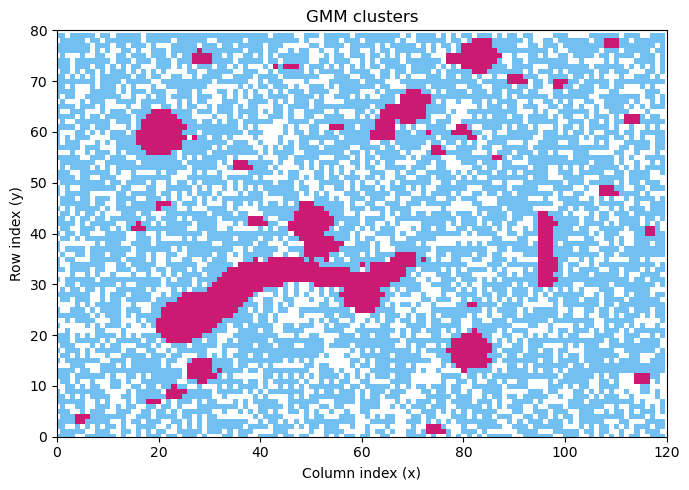

In [37]:
plot_fullframe_clusters(
    idx_yx,
    best["labels"],
    frame_size=cal_img.shape,
    title=f"GMM clusters"
)

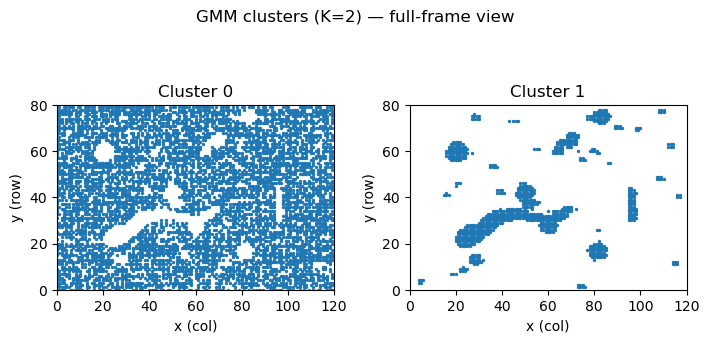

In [38]:
plot_cluster_gallery_on_frame(idx_yx, best, ccd_shape=cal_img.shape)

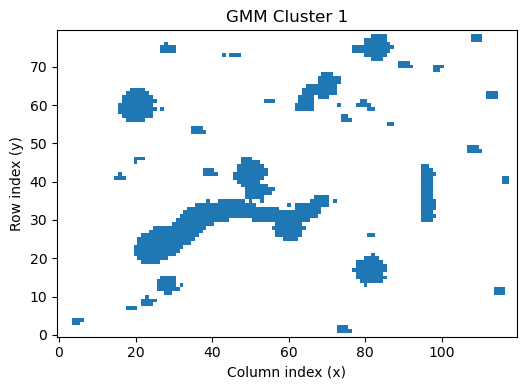

In [39]:
plot_one_cluster(idx_yx, best, ccd_shape=(80, 120), cluster_id=1)


In [40]:
import numpy as np
from scipy.ndimage import label as cc_label

def blobs_from_gmm(X_raw, gmm_labels, frame_size, cluster_id):
    """
    X_raw      : (N,3) array [y, x, E]
    gmm_labels : (N,) GMM labels (same order as X_raw)
    frame_size : (H, W)
    cluster_id : GMM component to extract

    Returns:
      blobs   : dict {blob_id: array [[y,x,E], ...]}
      labeled : (H,W) blob-ID image
    """
    H, W = frame_size

    sel = (gmm_labels == cluster_id)
    if not np.any(sel):
        labeled = np.zeros((H, W), dtype=int)
        return {}, labeled

    y = X_raw[sel, 0].astype(int)
    x = X_raw[sel, 1].astype(int)
    E = X_raw[sel, 2].astype(float)

    img = np.zeros((H, W), dtype=np.uint8)
    img[y, x] = 1

    # HARD-CODED 8-connectivity
    labeled = cc_label(img, structure=np.ones((3, 3), dtype=int))[0]

    blob_ids = labeled[y, x]
    blobs = {}

    for bid in np.unique(blob_ids):
        if bid == 0:
            continue
        m = (blob_ids == bid)
        blobs[bid] = np.column_stack([y[m], x[m], E[m]])  # [y,x,E]

    return blobs, labeled


In [41]:
blobs, labeled = blobs_from_gmm(
    X_raw=X_raw_cut,
    gmm_labels=best["labels"],
    frame_size=(80, 120),
    cluster_id=1
)

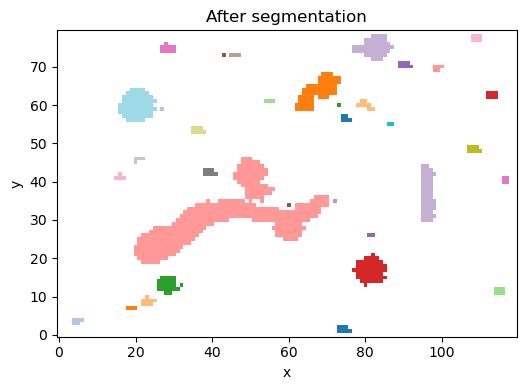

In [42]:
# build a colormap: 0 = white (background), blobs = colors
n_blobs = len(blobs)

colors = [(1, 1, 1, 1)]  # background = white
base = plt.cm.tab20.colors

for i in range(n_blobs):
    colors.append(base[i % len(base)])

cmap = ListedColormap(colors)

plt.figure(figsize=(6, 4))
plt.imshow(labeled, origin="lower", cmap=cmap, interpolation="none")
plt.title("After segmentation")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


In [43]:
# how many blobs
print("Number of blobs:", len(blobs))

# pick a blob ID (e.g. first one)
bid = list(blobs.keys())[0]

blob = blobs[bid]
print(f"Blob {bid} has {len(blob)} pixels")
print("First 10 pixels [y, x, E]:")
print(blob[:10])

Number of blobs: 34
Blob 1 has 7 pixels
First 10 pixels [y, x, E]:
[[1.00000000e+00 7.30000000e+01 7.81794892e-01]
 [1.00000000e+00 7.40000000e+01 1.24474309e+00]
 [1.00000000e+00 7.50000000e+01 6.83704288e-02]
 [1.00000000e+00 7.60000000e+01 1.48870188e-02]
 [2.00000000e+00 7.30000000e+01 1.25628726e+00]
 [2.00000000e+00 7.40000000e+01 2.36581875e+00]
 [2.00000000e+00 7.50000000e+01 1.55373053e-01]]


In [44]:
df_blobs = pd.DataFrame(
    {
        "blob_id": list(blobs.keys()),
        "points": list(blobs.values())
    }
)

In [45]:
df_blobs.head()

,blob_id,points
0,1,"[[1.0, 73.0, 0.7817948915907716], [1.0, 74.0, ..."
1,2,"[[3.0, 4.0, 0.9736312225443279], [3.0, 5.0, 0...."
2,3,"[[7.0, 18.0, 5.457328452274309], [7.0, 19.0, 0..."
3,4,"[[8.0, 22.0, 0.2227498012622869], [8.0, 23.0, ..."
4,5,"[[11.0, 28.0, 0.015138832633503293], [11.0, 29..."


In [46]:
df_blobs["cluster_size"] = df_blobs["points"].apply(len)

In [47]:
df_blobs.head()

,blob_id,points,cluster_size
0,1,"[[1.0, 73.0, 0.7817948915907716], [1.0, 74.0, ...",7
1,2,"[[3.0, 4.0, 0.9736312225443279], [3.0, 5.0, 0....",5
2,3,"[[7.0, 18.0, 5.457328452274309], [7.0, 19.0, 0...",3
3,4,"[[8.0, 22.0, 0.2227498012622869], [8.0, 23.0, ...",8
4,5,"[[11.0, 28.0, 0.015138832633503293], [11.0, 29...",23


In [48]:
df_blobs["energy"] = df_blobs["points"].apply(
    lambda pts: np.sum(np.asarray(pts)[:, 2])
)

In [49]:
df_blobs.head()

,blob_id,points,cluster_size,energy
0,1,"[[1.0, 73.0, 0.7817948915907716], [1.0, 74.0, ...",7,5.887274
1,2,"[[3.0, 4.0, 0.9736312225443279], [3.0, 5.0, 0....",5,5.903545
2,3,"[[7.0, 18.0, 5.457328452274309], [7.0, 19.0, 0...",3,5.879164
3,4,"[[8.0, 22.0, 0.2227498012622869], [8.0, 23.0, ...",8,5.865124
4,5,"[[11.0, 28.0, 0.015138832633503293], [11.0, 29...",23,8.193390


In [50]:

def weighted_std_xy(points):
    """
    points: array of shape (N,3) with columns [y, x, E]
    Returns: wSTD_y, wSTD_x
    """
    y = points[:, 0]
    x = points[:, 1]
    E = points[:, 2]

    Etot = E.sum()
    if Etot == 0:
        return np.nan, np.nan

    y_bar = np.sum(E * y) / Etot
    x_bar = np.sum(E * x) / Etot

    wSTD_y = np.sqrt(np.sum(E * (y - y_bar)**2) / Etot)
    wSTD_x = np.sqrt(np.sum(E * (x - x_bar)**2) / Etot)

    return wSTD_y, wSTD_x

In [51]:
df_blobs[["wSTD_y", "wSTD_x"]] = (
    df_blobs["points"]
    .apply(lambda pts: pd.Series(weighted_std_xy(pts)))
)

In [52]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x
0,1,"[[1.0, 73.0, 0.7817948915907716], [1.0, 74.0, ...",7,5.887274,4.795202e-01,0.549928
1,2,"[[3.0, 4.0, 0.9736312225443279], [3.0, 5.0, 0....",5,5.903545,4.438894e-01,0.502992
2,3,"[[7.0, 18.0, 5.457328452274309], [7.0, 19.0, 0...",3,5.879164,8.881784e-16,0.276205
3,4,"[[8.0, 22.0, 0.2227498012622869], [8.0, 23.0, ...",8,5.865124,3.133556e-01,0.535035
4,5,"[[11.0, 28.0, 0.015138832633503293], [11.0, 29...",23,8.193390,7.802767e-01,0.875431


In [53]:
df_blobs["wSTD_xy"] = np.sqrt(
    0.5 * (df_blobs["wSTD_x"]**2 + df_blobs["wSTD_y"]**2)
)

In [54]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x,wSTD_xy
0,1,"[[1.0, 73.0, 0.7817948915907716], [1.0, 74.0, ...",7,5.887274,4.795202e-01,0.549928,0.515926
1,2,"[[3.0, 4.0, 0.9736312225443279], [3.0, 5.0, 0....",5,5.903545,4.438894e-01,0.502992,0.474362
2,3,"[[7.0, 18.0, 5.457328452274309], [7.0, 19.0, 0...",3,5.879164,8.881784e-16,0.276205,0.195306
3,4,"[[8.0, 22.0, 0.2227498012622869], [8.0, 23.0, ...",8,5.865124,3.133556e-01,0.535035,0.438437
4,5,"[[11.0, 28.0, 0.015138832633503293], [11.0, 29...",23,8.193390,7.802767e-01,0.875431,0.829220


lets make these plots!

1. Energy vs. wSTD_xy

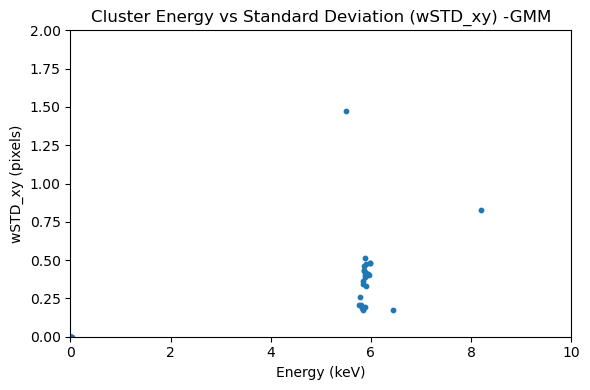

In [55]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["wSTD_xy"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("wSTD_xy (pixels)")
plt.xlim(0,10)
plt.ylim(0,2)
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) -GMM")
plt.tight_layout()
plt.show()


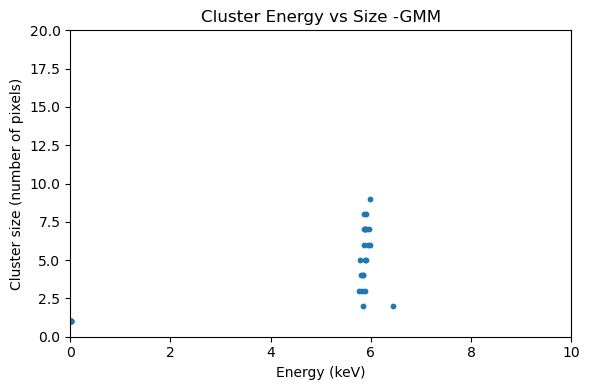

In [56]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["cluster_size"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("Cluster size (number of pixels)")
plt.title("Cluster Energy vs Size -GMM")
plt.xlim(0,10)
plt.ylim(0,20)
plt.tight_layout()
plt.show()

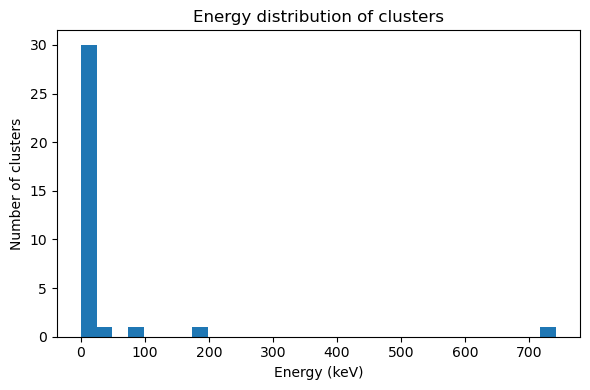

In [57]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=30)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters")
plt.tight_layout()
plt.show()

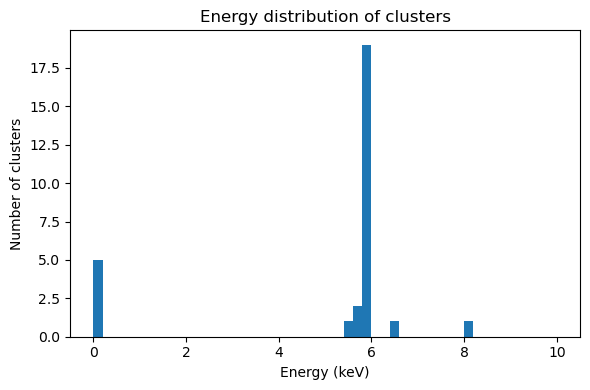

In [58]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=50, range=(0, 10))
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters")
plt.tight_layout()
plt.show()

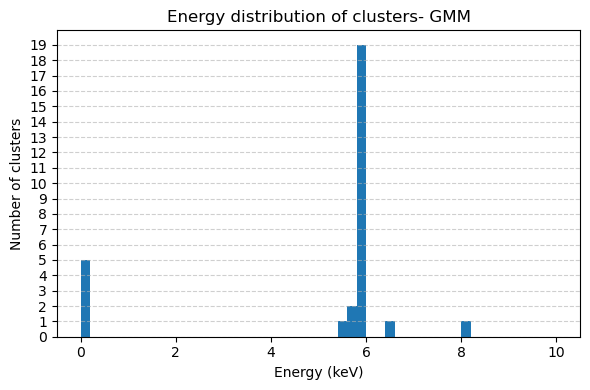

In [59]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=50, range=(0, 10))
# range=(0, 10)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters- GMM")

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- light grid aligned with ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

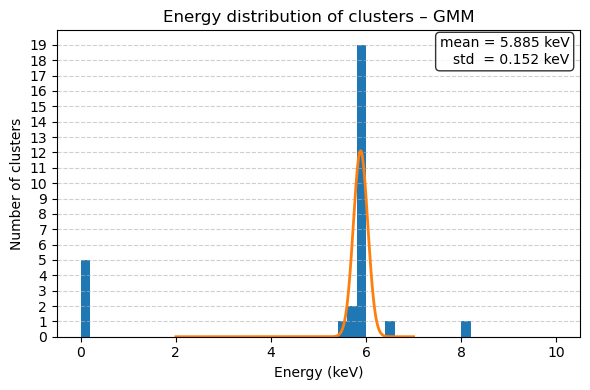

Gaussian fit using 2–7 keV only: mean=5.884948, std=0.151507


In [88]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

# --- histogram settings ---
bins = 50
hist_range = (0, 10)

# --- fit range (exclude low-energy peak AND high-energy tail) ---
fit_min, fit_max = 2.0, 7.0   # <<< CHANGED

data = df_blobs["energy"].to_numpy(dtype=float)
data = data[np.isfinite(data)]

# --- data used for fitting ONLY ---
fit_data = data[(data >= fit_min) & (data <= fit_max)]   # <<< SAME LOGIC

# --- Gaussian MLE fit on restricted range ---
mu, sigma = norm.fit(fit_data)

# --- plot histogram (ALL data) ---
plt.figure(figsize=(6, 4))
counts, bin_edges, _ = plt.hist(data, bins=bins, range=hist_range)

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – GMM")

# --- overlay Gaussian ONLY over fit range ---
bin_width = bin_edges[1] - bin_edges[0]
x = np.linspace(fit_min, fit_max, 500)   # <<< CHANGED
pdf = norm.pdf(x, loc=mu, scale=sigma)

# scale PDF to histogram counts
y = pdf * len(fit_data) * bin_width
plt.plot(x, y, linewidth=2)

# --- annotate fit ---
plt.text(
    0.98, 0.98,  
    f"mean = {mu:.3f} keV\n"
    f"std  = {sigma:.3f} keV",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- grid ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Gaussian fit using 2–7 keV only: mean={mu:.6f}, std={sigma:.6f}")


### GMM no background removal

### Waders clusters

In [61]:
import uproot

In [62]:
file = "/home/dsalma/damicm-ml/cut_images/cut_images/panaSKImg_clustersRec_cutout_img_8_ext1.root"

In [63]:
with uproot.open(file) as f:
    print(f.keys())

['clustersRec;1', 'info;1', 'process_config;1']


In [64]:
clustersRec_tree = f["clustersRec"]

In [65]:
df = clustersRec_tree.arrays(library="pd")

In [66]:
try:
    import awkward as ak
except Exception:
    ak = None

def to_list_maybe(x):
    # Handle common array-likes
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return list(x)
    # Awkward arrays
    if ak is not None:
        try:
            return ak.to_list(x)
        except Exception:
            pass
    # Some awkward objects have .to_list()
    if hasattr(x, "to_list"):
        try:
            return x.to_list()
        except Exception:
            pass
    # Not an array -> return None so we can repeat later
    return None

# --- Choose columns (drop the blockers) ---
cols = [c for c in df.columns if c not in ["RUNID", "Nclusters"]]

# Use the first row (you said there's 1 row)
row = df.iloc[0]

# Find target length (e.g., 991) from the first array-like column
N = None
for c in cols:
    seq = to_list_maybe(row[c])
    if seq is not None:
        N = len(seq)
        break
if N is None:
    raise ValueError("Couldn't find any array-like columns to expand.")

# Build dict of columns -> sequences (repeat scalars)
data = {}
for c in cols:
    seq = to_list_maybe(row[c])
    if seq is None:
        # scalar: repeat it N times
        data[c] = [row[c]] * N
    else:
        data[c] = seq

df_expanded = pd.DataFrame(data).reset_index(drop=True)

print(df_expanded.shape)  
df_expanded.head()

(30, 57)


,DX,DY,Energy,Energy_AVG,Energy_PS,Npix,PosX,PosY,Qmax,QmaxX,...,readout_end,readout_start,seed_nsig_delta,seed_nsig_max,seed_nsig_min,seed_nsig_pixels,sigma_seed_eV,wSTD_X,wSTD_XY,wSTD_Y
0,14.0,12.0,194.464111,65958.757812,69097.156250,77,68.918869,65.107002,15.169851,70.0,...,1.763462e+09,1.763404e+09,36244.703125,36254.843750,10.138350,"[10.285340309143066, 18.475154876708984, 878.5...",0.418423,2.470858,2.256300,2.019069
1,5.0,2.0,5.891742,1767.417236,2093.458984,8,74.699379,2.641148,2.365819,75.0,...,1.763462e+09,1.763404e+09,5643.457520,5654.135254,10.677445,"[1868.4329833984375, 2974.845703125, 163.40036...",0.418423,0.557188,0.519873,0.479664
2,4.0,2.0,5.918036,1817.442871,2102.801514,7,5.383049,4.729544,2.751958,5.0,...,1.763462e+09,1.763404e+09,6560.059082,6576.979980,16.920906,"[2326.907958984375, 1480.62646484375, 17.71242...",0.418423,0.513688,0.480200,0.444196
3,5.0,3.0,5.847705,1833.357178,2077.811768,6,55.072155,61.997234,5.442732,55.0,...,1.763462e+09,1.763404e+09,12997.110352,13007.733398,10.623728,"[10.623727798461914, 17.413532257080078, 13007...",0.418423,0.297661,0.215501,0.065414
4,14.0,4.0,6.049662,1131.708740,2149.571045,25,80.008987,61.116169,4.760489,80.0,...,1.763462e+09,1.763404e+09,11367.204102,11377.223633,10.019772,"[17.267242431640625, 17.267242431640625, 17.26...",0.418423,0.801591,0.622548,0.364121


In [67]:
df_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 57 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DX                  30 non-null     float64
 1   DY                  30 non-null     float64
 2   Energy              30 non-null     float64
 3   Energy_AVG          30 non-null     float64
 4   Energy_PS           30 non-null     float64
 5   Npix                30 non-null     int64  
 6   PosX                30 non-null     float64
 7   PosY                30 non-null     float64
 8   Qmax                30 non-null     float64
 9   QmaxX               30 non-null     float64
 10  QmaxY               30 non-null     float64
 11  RMSX                30 non-null     float64
 12  RMSY                30 non-null     float64
 13  STD_X               30 non-null     float64
 14  STD_XY              30 non-null     float64
 15  STD_Y               30 non-null     float64
 16  ccd       

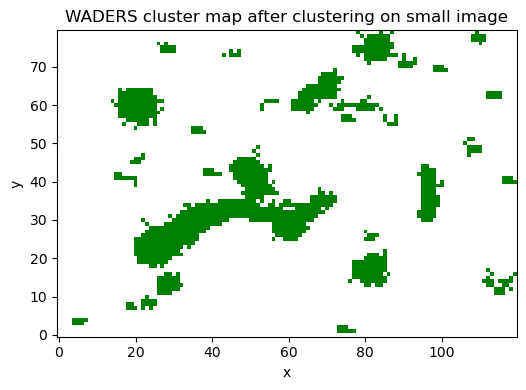

In [68]:
H, W = 80, 120
img = np.zeros((H, W), dtype=int)

for _, row in df_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = 1   # mark cluster pixels

# custom colormap: 0 -> white, 1 -> green
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(6, 4))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("WADERS cluster map after clustering on small image")
plt.tight_layout()
plt.show()


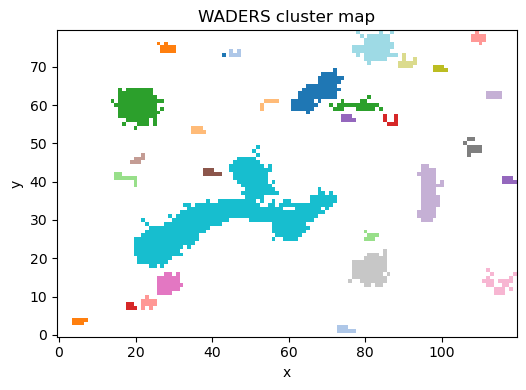

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

H, W = 80, 120
img = np.zeros((H, W), dtype=int)

# assign a unique label to each cluster (starting from 1)
for label, (_, row) in enumerate(df_expanded.iterrows(), start=1):
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = label

# build a colormap: 0 = white, clusters = tab20 colors
n_clusters = len(df_expanded)
colors = ["white"] + list(plt.cm.tab20.colors) * ((n_clusters // 20) + 1)
cmap = ListedColormap(colors[: n_clusters + 1])

plt.figure(figsize=(6, 4))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("WADERS cluster map")
plt.tight_layout()
plt.show()


In [70]:
len(df_expanded)

30

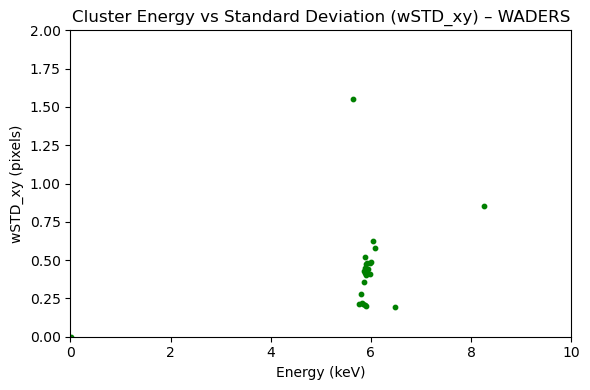

In [71]:
plt.figure(figsize=(6, 4))
plt.scatter(df_expanded["Energy"], df_expanded["wSTD_XY"], s=10, c="green")
plt.xlabel("Energy (keV)")
plt.ylabel("wSTD_xy (pixels)")
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) – WADERS")
plt.xlim(0,10)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

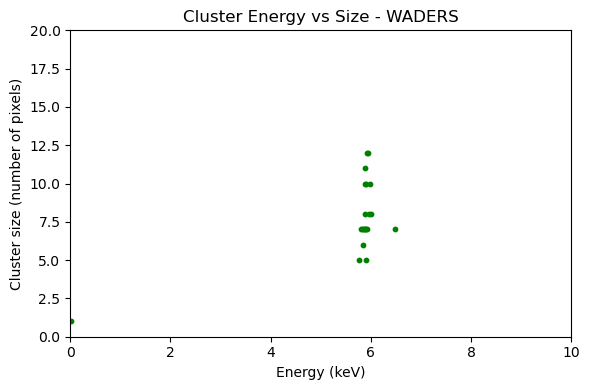

In [72]:
plt.figure(figsize=(6, 4))
plt.scatter(df_expanded["Energy"], df_expanded["Npix"], s=10, c="green")
plt.xlabel("Energy (keV)")
plt.ylabel("Cluster size (number of pixels)")
plt.title("Cluster Energy vs Size - WADERS")
plt.xlim(0,10)
plt.ylim(0,20)
plt.tight_layout()
plt.show()

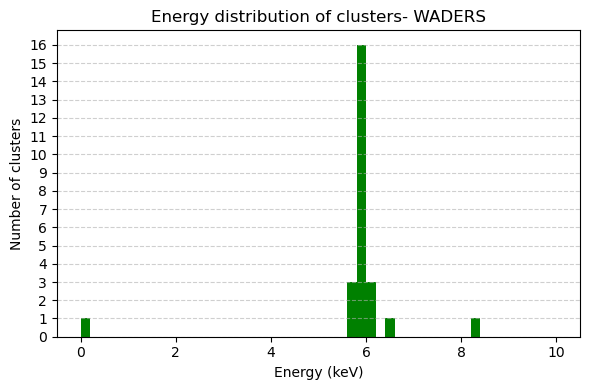

In [73]:
plt.figure(figsize=(6, 4))
plt.hist(df_expanded["Energy"], bins=50, color="green", range=(0, 10))
# range=(0, 10)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters- WADERS")

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- light grid aligned with ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

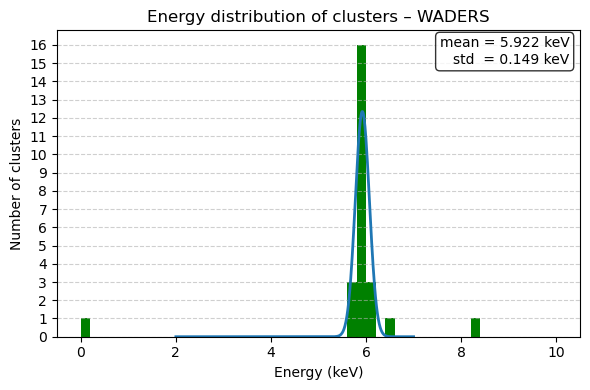

Gaussian fit (2–7 keV): mean=5.922043, std=0.148565


In [90]:
from scipy.stats import norm

# --- settings ---
bins = 50
hist_range = (0, 10)
fit_min, fit_max = 2.0, 7.0

# --- extract energy ---
data = df_expanded["Energy"].to_numpy(dtype=float)
data = data[np.isfinite(data)]

# --- data used ONLY for Gaussian fit ---
fit_data = data[(data >= fit_min) & (data <= fit_max)]

# --- Gaussian MLE fit ---
mu, sigma = norm.fit(fit_data)

# --- plot histogram (unchanged from yours) ---
plt.figure(figsize=(6, 4))
counts, bin_edges, _ = plt.hist(
    data, bins=bins, color="green", range=hist_range
)

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – WADERS")

# --- overlay Gaussian ONLY over 2–7 keV ---
bin_width = bin_edges[1] - bin_edges[0]
x = np.linspace(fit_min, fit_max, 500)
pdf = norm.pdf(x, loc=mu, scale=sigma)

# scale PDF to histogram counts
y = pdf * len(fit_data) * bin_width
plt.plot(x, y, linewidth=2)

# --- annotate fit ---
plt.text(
    0.98, 0.98,
    f"mean = {mu:.3f} keV\n"
    f"std  = {sigma:.3f} keV",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- grid ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Gaussian fit (2–7 keV): mean={mu:.6f}, std={sigma:.6f}")


In [75]:
H, W = 80, 120  # your small image size

# --- GMM mask from df_blobs["points"] which stores [y,x,E] arrays ---
gmm_mask = np.zeros((H, W), dtype=bool)
for pts in df_blobs["points"]:
    pts = np.asarray(pts)
    ys = pts[:, 0].astype(int)
    xs = pts[:, 1].astype(int)
    gmm_mask[ys, xs] = True

# --- WADERS mask from df_expanded pixels_x/pixels_y (1-based -> convert to 0-based) ---
waders_mask = np.zeros((H, W), dtype=bool)
for _, row in df_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    waders_mask[ys, xs] = True

overlap_mask = gmm_mask & waders_mask

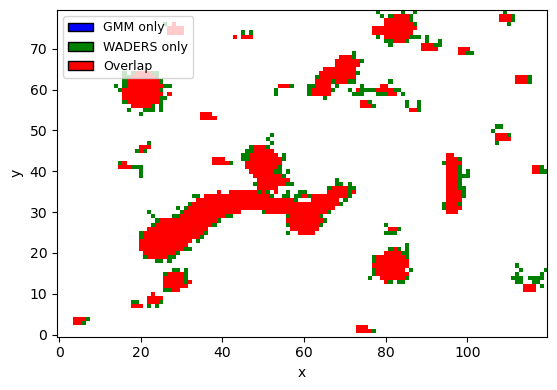

In [76]:
from matplotlib.patches import Patch


overlay = np.zeros((H, W), dtype=int)
overlay[gmm_mask & ~waders_mask] = 1
overlay[waders_mask & ~gmm_mask] = 2
overlay[overlap_mask] = 3

cmap_overlay = ListedColormap(["white", "blue", "green", "red"])

plt.figure(figsize=(6, 4))
plt.imshow(overlay, origin="lower", cmap=cmap_overlay, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")

# --- legend ---
legend_elements = [
    Patch(facecolor="blue",  edgecolor="black", label="GMM only"),
    Patch(facecolor="green", edgecolor="black", label="WADERS only"),
    Patch(facecolor="red",   edgecolor="black", label="Overlap"),
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.show()


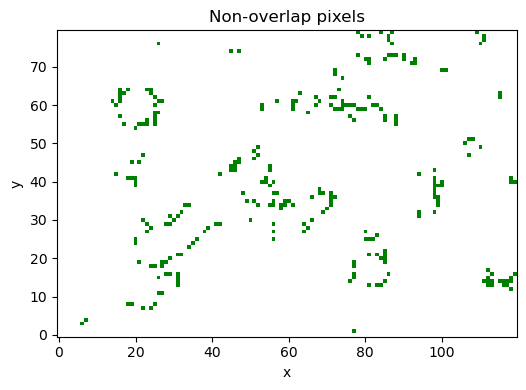

In [77]:
no_overlap = np.zeros((H, W), dtype=int)
no_overlap[gmm_mask & ~waders_mask] = 1
no_overlap[waders_mask & ~gmm_mask] = 2
# overlap pixels stay 0 (white)

cmap_no = ListedColormap(["white", "blue", "green"])

plt.figure(figsize=(6, 4))
plt.imshow(no_overlap, origin="lower", cmap=cmap_no, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Non-overlap pixels")
plt.tight_layout()
plt.show()


### Comparison between 2 clustering approaches

Peak bin: [5.800, 6.000) keV | n_blobs=19


/tmp/ipykernel_183733/2085816532.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))


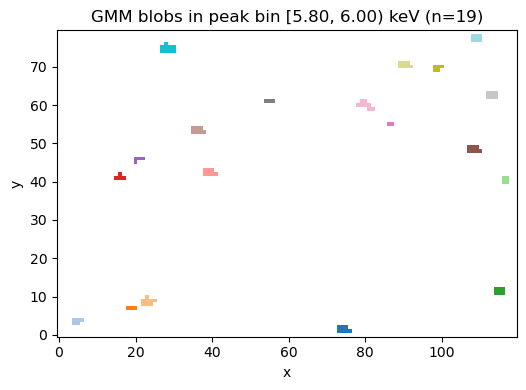

In [78]:
# --- match your histogram ---
BINS = 50
HIST_RANGE = (0, 10)

# 1) peak bin
e = df_blobs["energy"].to_numpy(float)
e = e[np.isfinite(e)]

counts, edges = np.histogram(e, bins=BINS, range=HIST_RANGE)
peak_idx = int(np.argmax(counts))
E_lo, E_hi = float(edges[peak_idx]), float(edges[peak_idx + 1])

df_peak = df_blobs[df_blobs["energy"].between(E_lo, E_hi, inclusive="left")].copy()
print(f"Peak bin: [{E_lo:.3f}, {E_hi:.3f}) keV | n_blobs={len(df_peak)}")

# 2) label map ONLY for those blobs (use cut image dimensions)
H, W = cal_img.shape
labels = np.full((H, W), np.nan, dtype=float)

for j, (_, row) in enumerate(df_peak.iterrows()):
    pts = np.asarray(row["points"], dtype=float)   # [y, x, E]
    ys = pts[:, 0].astype(int)
    xs = pts[:, 1].astype(int)

    m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    labels[ys[m], xs[m]] = j

# 3) plot
cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))
cmap.set_bad("white")

plt.figure(figsize=(6, 4))
plt.imshow(labels, origin="lower", cmap=cmap, interpolation="none")
plt.title(f"GMM blobs in peak bin [{E_lo:.2f}, {E_hi:.2f}) keV (n={len(df_peak)})")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


Peak bin: [5.800, 6.000) keV | n_blobs=19


/tmp/ipykernel_183733/2788343808.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))


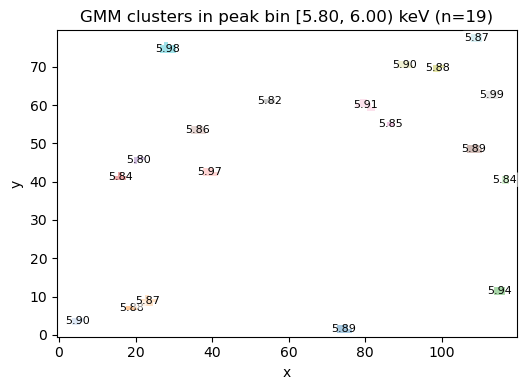

In [79]:
# --- match your histogram ---
BINS = 50
HIST_RANGE = (0, 10)

# 1) peak bin
e = df_blobs["energy"].to_numpy(float)
e = e[np.isfinite(e)]

counts, edges = np.histogram(e, bins=BINS, range=HIST_RANGE)
peak_idx = int(np.argmax(counts))
E_lo, E_hi = float(edges[peak_idx]), float(edges[peak_idx + 1])

df_peak = df_blobs[df_blobs["energy"].between(E_lo, E_hi, inclusive="left")].copy()
print(f"Peak bin: [{E_lo:.3f}, {E_hi:.3f}) keV | n_blobs={len(df_peak)}")

# 2) label map ONLY for those blobs
H, W = cal_img.shape
labels = np.full((H, W), np.nan, dtype=float)

# store centroids for annotation
centroids = []

for j, (_, row) in enumerate(df_peak.iterrows()):
    pts = np.asarray(row["points"], dtype=float)   # [y, x, E]
    ys = pts[:, 0].astype(int)
    xs = pts[:, 1].astype(int)

    m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[m], ys[m]

    labels[ys, xs] = j

    # centroid in image coordinates
    cx = xs.mean()
    cy = ys.mean()
    centroids.append((cx, cy, row["energy"]))

# 3) plot
cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))
cmap.set_bad("white")

plt.figure(figsize=(6, 4))
plt.imshow(labels, origin="lower", cmap=cmap, interpolation="none")

# annotate energies
for cx, cy, E in centroids:
    plt.text(
        cx, cy, f"{E:.2f}",
        ha="center", va="center",
        fontsize=8,
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
    )

plt.title(f"GMM clusters in peak bin [{E_lo:.2f}, {E_hi:.2f}) keV (n={len(df_peak)})")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


Peak bin: [5.800, 6.000) keV | n_clusters=16


/tmp/ipykernel_183733/2798110327.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))


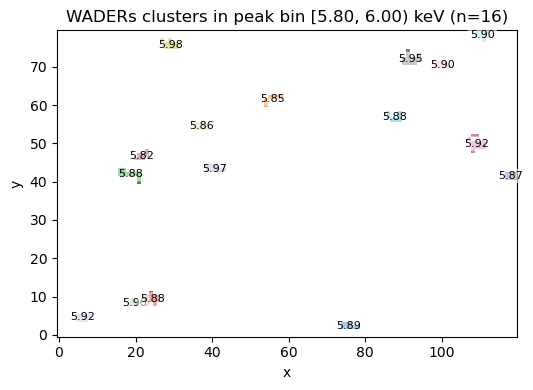

In [80]:
# --- match your histogram settings ---
BINS = 50
HIST_RANGE = (0, 10)

# 1) peak bin (classical)
e = df_expanded["Energy"].to_numpy(float)
e = e[np.isfinite(e)]

counts, edges = np.histogram(e, bins=BINS, range=HIST_RANGE)
peak_idx = int(np.argmax(counts))
E_lo, E_hi = float(edges[peak_idx]), float(edges[peak_idx + 1])

df_peak = df_expanded[df_expanded["Energy"].between(E_lo, E_hi, inclusive="left")].copy()
print(f"Peak bin: [{E_lo:.3f}, {E_hi:.3f}) keV | n_clusters={len(df_peak)}")

# 2) label map ONLY for those clusters (use cut image dimensions)
H, W = cal_img.shape
labels = np.full((H, W), np.nan, dtype=float)

centroids = []

for j, (_, row) in enumerate(df_peak.iterrows()):
    xs = np.asarray(row["pixels_x"], dtype=int)
    ys = np.asarray(row["pixels_y"], dtype=int)

    # keep in-bounds
    m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[m], ys[m]
    if xs.size == 0:
        continue

    labels[ys, xs] = j

    # centroid for label
    cx = xs.mean()
    cy = ys.mean()
    centroids.append((cx, cy, float(row["Energy"])))

# 3) plot
cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))
cmap.set_bad("white")

plt.figure(figsize=(6, 4))
plt.imshow(labels, origin="lower", cmap=cmap, interpolation="none")

# annotate energies
for cx, cy, E in centroids:
    plt.text(
        cx, cy, f"{E:.2f}",
        ha="center", va="center",
        fontsize=8,
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
    )

plt.title(f"WADERs clusters in peak bin [{E_lo:.2f}, {E_hi:.2f}) keV (n={len(df_peak)})")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


GMM bins:
  prev: idx=28, [5.600, 5.800) keV, count=2
  peak: idx=29, [5.800, 6.000) keV, count=19
  next: idx=30, [6.000, 6.200) keV, count=0


/tmp/ipykernel_183733/109059660.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = plt.cm.get_cmap("tab10")


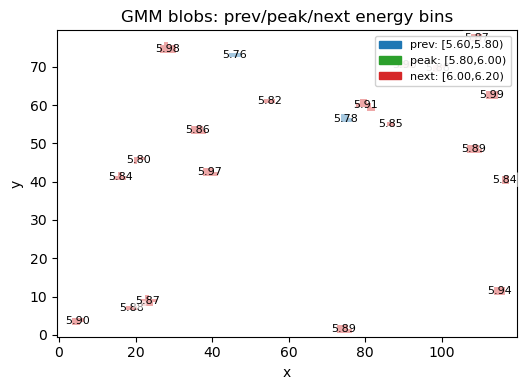

In [81]:
BINS = 50
HIST_RANGE = (0, 10)

# --- peak bin on GMM ---
e = df_blobs["energy"].to_numpy(float)
e = e[np.isfinite(e)]

counts, edges = np.histogram(e, bins=BINS, range=HIST_RANGE)
peak_idx = int(np.argmax(counts))

# indices we want: previous, peak, next (clip at edges)
bin_idxs = [max(peak_idx - 1, 0), peak_idx, min(peak_idx + 1, len(edges) - 2)]
bin_names = ["prev", "peak", "next"]

print("GMM bins:")
for name, bi in zip(bin_names, bin_idxs):
    print(f"  {name}: idx={bi}, [{edges[bi]:.3f}, {edges[bi+1]:.3f}) keV, count={counts[bi]}")

H, W = cal_img.shape
labels = np.full((H, W), np.nan, dtype=float)
centroids = []

# color-class map: 0=prev, 1=peak, 2=next
bin_to_class = {bin_idxs[0]: 0, bin_idxs[1]: 1, bin_idxs[2]: 2}

# build masks for each bin class and draw blobs
for class_id, bi in enumerate(bin_idxs):
    lo, hi = float(edges[bi]), float(edges[bi + 1])
    df_bin = df_blobs[df_blobs["energy"].between(lo, hi, inclusive="left")]

    for _, row in df_bin.iterrows():
        pts = np.asarray(row["points"], dtype=float)  # [y, x, E]
        ys = pts[:, 0].astype(int)
        xs = pts[:, 1].astype(int)

        m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
        xs, ys = xs[m], ys[m]
        if xs.size == 0:
            continue

        labels[ys, xs] = class_id  # <- ONLY 3 colors, by bin
        centroids.append((xs.mean(), ys.mean(), float(row["energy"]), class_id))

# --- plot ---
# pick 3 distinct colors from tab10
tab10 = plt.cm.get_cmap("tab10")
cmap = ListedColormap([tab10(0), tab10(2), tab10(3)])  # prev, peak, next
cmap.set_bad("white")

plt.figure(figsize=(6, 4))
plt.imshow(labels, origin="lower", cmap=cmap, interpolation="none")

# energy labels
for cx, cy, E, class_id in centroids:
    plt.text(
        cx, cy, f"{E:.2f}",
        ha="center", va="center", fontsize=8, color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
    )

# legend with bin edges
legend_patches = []
for class_id, name, bi in zip([0,1,2], bin_names, bin_idxs):
    lo, hi = edges[bi], edges[bi+1]
    legend_patches.append(Patch(color=cmap(class_id), label=f"{name}: [{lo:.2f},{hi:.2f})"))
plt.legend(handles=legend_patches, loc="upper right", fontsize=8, framealpha=0.9)

plt.title("GMM blobs: prev/peak/next energy bins")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()
plt.show()


prev: [5.60,5.80)  peak: [5.80,6.00)  next: [6.00,6.20)


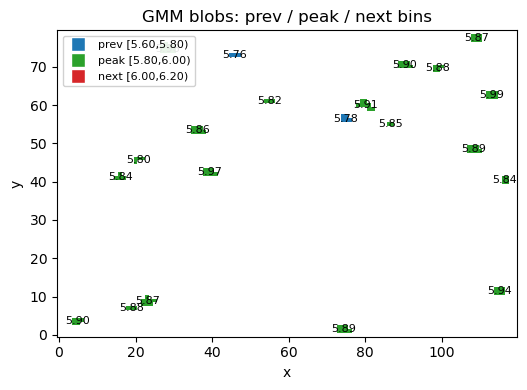

In [82]:
# Must match your histogram
BINS = 50
HIST_RANGE = (0, 10)

# --- compute histogram edges + peak bin ---
e = df_blobs["energy"].to_numpy(float)
e = e[np.isfinite(e)]
counts, edges = np.histogram(e, bins=BINS, range=HIST_RANGE)

peak_idx = int(np.argmax(counts))
prev_idx = max(peak_idx - 1, 0)
next_idx = min(peak_idx + 1, len(edges) - 2)

prev_lo, prev_hi = float(edges[prev_idx]), float(edges[prev_idx + 1])
peak_lo, peak_hi = float(edges[peak_idx]), float(edges[peak_idx + 1])
next_lo, next_hi = float(edges[next_idx]), float(edges[next_idx + 1])

print(f"prev: [{prev_lo:.2f},{prev_hi:.2f})  peak: [{peak_lo:.2f},{peak_hi:.2f})  next: [{next_lo:.2f},{next_hi:.2f})")

# --- label image (store class ids 0,1,2) ---
H, W = cal_img.shape
cls = np.full((H, W), -1, dtype=np.int8)  # -1 = background

centroids = []  # (cx, cy, E)

def class_from_energy(E):
    if prev_lo <= E < prev_hi: return 0
    if peak_lo <= E < peak_hi: return 1
    if next_lo <= E < next_hi: return 2
    return None

# --- single pass: each blob decides its own color ---
for _, row in df_blobs.iterrows():
    E = float(row["energy"])
    c = class_from_energy(E)
    if c is None:
        continue

    pts = np.asarray(row["points"], dtype=float)  # [y, x, Epix]
    ys = pts[:, 0].astype(int)
    xs = pts[:, 1].astype(int)

    m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[m], ys[m]
    if xs.size == 0:
        continue

    cls[ys, xs] = c
    centroids.append((xs.mean(), ys.mean(), E))

# --- plot ---
# build an RGB image so there is ZERO ambiguity about mapping
rgb = np.ones((H, W, 3), dtype=float)  # white background

# prev = blue, peak = green, next = red
rgb[cls == 0] = (0.12, 0.47, 0.71)  # blue-ish
rgb[cls == 1] = (0.17, 0.63, 0.17)  # green-ish
rgb[cls == 2] = (0.84, 0.15, 0.16)  # red-ish

plt.figure(figsize=(6, 4))
plt.imshow(rgb, origin="lower", interpolation="none")

# optional text (remove if you want)
for cx, cy, E in centroids:
    plt.text(cx, cy, f"{E:.2f}", ha="center", va="center", fontsize=8, color="black")

plt.title("GMM blobs: prev / peak / next bins")
plt.xlabel("x"); plt.ylabel("y")

# simple legend
plt.legend(
    handles=[
        plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.12,0.47,0.71), markersize=10,
                   label=f"prev [{prev_lo:.2f},{prev_hi:.2f})"),
        plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.17,0.63,0.17), markersize=10,
                   label=f"peak [{peak_lo:.2f},{peak_hi:.2f})"),
        plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.84,0.15,0.16), markersize=10,
                   label=f"next [{next_lo:.2f},{next_hi:.2f})"),
    ],
    loc="upper left",
    fontsize=8,
    framealpha=0.9
)

plt.tight_layout()
plt.show()


prev: [5.60,5.80)  peak: [5.80,6.00)  next: [6.00,6.20)


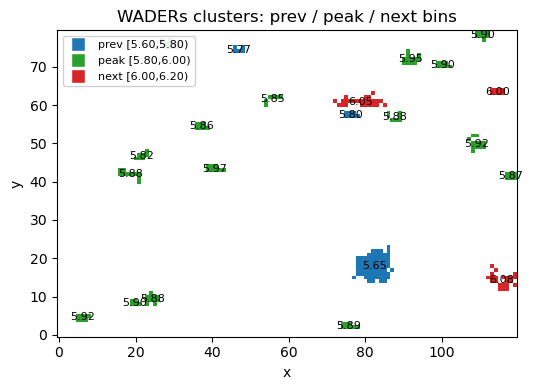

In [83]:
# Must match your histogram
BINS = 50
HIST_RANGE = (0, 10)

# --- compute histogram edges + peak bin (CLASSICAL) ---
e = df_expanded["Energy"].to_numpy(float)
e = e[np.isfinite(e)]
counts, edges = np.histogram(e, bins=BINS, range=HIST_RANGE)

peak_idx = int(np.argmax(counts))
prev_idx = max(peak_idx - 1, 0)
next_idx = min(peak_idx + 1, len(edges) - 2)

prev_lo, prev_hi = float(edges[prev_idx]), float(edges[prev_idx + 1])
peak_lo, peak_hi = float(edges[peak_idx]), float(edges[peak_idx + 1])
next_lo, next_hi = float(edges[next_idx]), float(edges[next_idx + 1])

print(f"prev: [{prev_lo:.2f},{prev_hi:.2f})  peak: [{peak_lo:.2f},{peak_hi:.2f})  next: [{next_lo:.2f},{next_hi:.2f})")

# --- label image (store class ids 0,1,2) ---
H, W = cal_img.shape
cls = np.full((H, W), -1, dtype=np.int8)  # -1 = background

centroids = []  # (cx, cy, E)

def class_from_energy(E):
    if prev_lo <= E < prev_hi: return 0
    if peak_lo <= E < peak_hi: return 1
    if next_lo <= E < next_hi: return 2
    return None

# --- single pass: each cluster decides its own color ---
for _, row in df_expanded.iterrows():
    E = float(row["Energy"])
    c = class_from_energy(E)
    if c is None:
        continue

    xs = np.asarray(row["pixels_x"], dtype=int)
    ys = np.asarray(row["pixels_y"], dtype=int)

    m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[m], ys[m]
    if xs.size == 0:
        continue

    cls[ys, xs] = c
    centroids.append((xs.mean(), ys.mean(), E))

# --- plot (RGB, no ambiguity) ---
rgb = np.ones((H, W, 3), dtype=float)  # white background

# prev = blue, peak = green, next = red
rgb[cls == 0] = (0.12, 0.47, 0.71)
rgb[cls == 1] = (0.17, 0.63, 0.17)
rgb[cls == 2] = (0.84, 0.15, 0.16)

plt.figure(figsize=(6, 4))
plt.imshow(rgb, origin="lower", interpolation="none")

# optional text (remove if you want)
for cx, cy, E in centroids:
    plt.text(cx, cy, f"{E:.2f}", ha="center", va="center", fontsize=8, color="black")

plt.title("WADERs clusters: prev / peak / next bins")
plt.xlabel("x"); plt.ylabel("y")

plt.legend(
    handles=[
        plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.12,0.47,0.71), markersize=10,
                   label=f"prev [{prev_lo:.2f},{prev_hi:.2f})"),
        plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.17,0.63,0.17), markersize=10,
                   label=f"peak [{peak_lo:.2f},{peak_hi:.2f})"),
        plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.84,0.15,0.16), markersize=10,
                   label=f"next [{next_lo:.2f},{next_hi:.2f})"),
    ],
    loc="upper left",
    fontsize=8,
    framealpha=0.9
)

plt.tight_layout()
plt.show()


In [84]:
x0, y0 = 80, 20

found = False

for _, row in df_blobs.iterrows():
    pts = np.asarray(row["points"], dtype=int)  # [y, x, E]
    ys = pts[:, 0]
    xs = pts[:, 1]

    # exact pixel membership test
    mask = (xs == x0) & (ys == y0)
    if np.any(mask):
        found = True
        print("Pixel IS in a GMM blob")
        print(f"  blob_id      = {row['blob_id']}")
        print(f"  energy (keV) = {row['energy']:.4f}")
        print(f"  cluster_size= {row['cluster_size']}")
        break

if not found:
    print(f"Pixel (x={x0}, y={y0}) is NOT contained in any GMM blob.")


Pixel IS in a GMM blob
  blob_id      = 7
  energy (keV) = 5.5029
  cluster_size= 51


In [85]:
labels = np.asarray(best["labels"])
ys_all = np.asarray(idx_yx[:, 0], dtype=int)
xs_all = np.asarray(idx_yx[:, 1], dtype=int)

# energies for cluster 1 (signal)
sel1 = (labels == 1)
E1 = cal_img[ys_all[sel1], xs_all[sel1]]
E1 = E1[np.isfinite(E1)]
min_sig = float(E1.min())

# energies for cluster 0 (background)
sel0 = (labels == 0)
E0 = cal_img[ys_all[sel0], xs_all[sel0]]
E0 = E0[np.isfinite(E0)]
max_bg = float(E0.max())

print(f"Cluster 1 (signal):     min pixel energy = {min_sig:.6f} keV")
print(f"Cluster 0 (background): max pixel energy = {max_bg:.6f} keV")

if min_sig > max_bg:
    print(f"Gap exists. Midpoint cutoff = {(0.5*(min_sig+max_bg)):.6f} keV")
else:
    print("Overlap exists: min(signal) <= max(background). No clean cutoff from extrema.")


Cluster 1 (signal):     min pixel energy = 0.014080 keV
Cluster 0 (background): max pixel energy = 0.014849 keV
Overlap exists: min(signal) <= max(background). No clean cutoff from extrema.


In [86]:
min_E = min(
    min(pixE)
    for pixE in df_expanded["pixels_E"]
    if len(pixE) > 0
)

print("Lowest WADERs pixel energy =", min_E)


Lowest WADERs pixel energy = 0.004192500375211239
